In [1]:
pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 77.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [2]:
import zipfile
import os

In [3]:
# Extract the dataset
def extract_dataset():
    dataset_path = "./TestDataSet/TestDataSet"
    zip_path = "./TestDataSet.zip"

    if not os.path.exists(dataset_path):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall("./TestDataSet")
        print("Dataset extracted successfully.")
    else:
        print("Dataset already exists.")

    return dataset_path

In [4]:
# Extract the dataset
dataset_path = extract_dataset()

Dataset extracted successfully.


In [5]:
import os
import json
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms, datasets
from torch.utils.data import DataLoader
from PIL import Image
import random
from tqdm import tqdm
import shutil


In [6]:

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained ResNet-34
pretrained_model = torchvision.models.resnet34(weights='IMAGENET1K_V1').to(device)
pretrained_model.eval()

# Load DenseNet-121 for Task 5
densenet = torchvision.models.densenet121(weights='IMAGENET1K_V1').to(device)
densenet.eval()

# Dataset parameters
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
plain_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 154MB/s]
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 100MB/s]


In [7]:
import json

# Load the JSON file
with open('labels_list.json', 'r') as f:
    class_list = json.load(f)  # This is a list, not a dict

# Create a dictionary mapping {class_index: class_name}
idx_to_class = {}
for item in class_list:
    index, name = item.split(": ")  # Split "401: accordion" into 401 and accordion
    idx_to_class[int(index)] = name

print(idx_to_class)
# Output: {401: 'accordion', 402: 'acoustic guitar', ...}

{401: 'accordion', 402: 'acoustic guitar', 403: 'aircraft carrier', 404: 'airliner', 405: 'airship', 406: 'altar', 407: 'ambulance', 408: 'amphibian', 409: 'analog clock', 410: 'apiary', 411: 'apron', 412: 'ashcan', 413: 'assault rifle', 414: 'backpack', 415: 'bakery', 416: 'balance beam', 417: 'balloon', 418: 'ballpoint', 419: 'Band Aid', 420: 'banjo', 421: 'bannister', 422: 'barbell', 423: 'barber chair', 424: 'barbershop', 425: 'barn', 426: 'barometer', 427: 'barrel', 428: 'barrow', 429: 'baseball', 430: 'basketball', 431: 'bassinet', 432: 'bassoon', 433: 'bathing cap', 434: 'bath towel', 435: 'bathtub', 436: 'beach wagon', 437: 'beacon', 438: 'beaker', 439: 'bearskin', 440: 'beer bottle', 441: 'beer glass', 442: 'bell cote', 443: 'bib', 444: 'bicycle-built-for-two', 445: 'bikini', 446: 'binder', 447: 'binoculars', 448: 'birdhouse', 449: 'boathouse', 450: 'bobsled', 451: 'bolo tie', 452: 'bonnet', 453: 'bookcase', 454: 'bookshop', 455: 'bottlecap', 456: 'bow', 457: 'bow tie', 458: '

In [8]:
# Get sorted subfolder names (WordNet IDs)
import os
subfolders = sorted(os.listdir(dataset_path))

# Create mapping: {subfolder_name: class_index}
folder_to_index = {subfolder: idx for idx, subfolder in enumerate(subfolders)}

In [9]:
dataset_path = "./TestDataSet/TestDataSet"
dataset = torchvision.datasets.ImageFolder(
    root=dataset_path,
    transform=plain_transforms
)
loader = DataLoader(dataset, batch_size=32, shuffle=False)

# Load class list
with open('labels_list.json', 'r') as f:
    class_list = json.load(f)

# Parse into {class_index: class_name}
idx_to_class = {}
for item in class_list:
    index, name = item.split(": ")
    idx_to_class[int(index)] = name

# Load dataset
dataset = torchvision.datasets.ImageFolder(
    root=dataset_path,
    transform=plain_transforms
)

# Example usage: get predicted class name
image, label_idx = dataset[0]  # label_idx is 0, 1, 2, ... (based on subfolder order)
predicted_class = idx_to_class[label_idx + 401]  # Offset by 401 if needed

In [10]:

# Evaluation function
def evaluate(model, dataloader):
    top1_correct = 0
    top5_correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.topk(outputs, 5, dim=1)

            # Offset labels from 0-99 → 401-500
            adjusted_labels = labels + 401

            # Check if any of the top-5 predictions match the adjusted label
            correct = preds.eq(adjusted_labels.view(-1, 1))
            top1_correct += correct[:, 0].sum().item()
            top5_correct += correct.any(dim=1).sum().item()
            total += labels.size(0)
    return top1_correct / total, top5_correct / total


In [22]:

# Task 1: Baseline evaluation
print("Task 1: Original Test Set Evaluation")
top1_orig, top5_orig = evaluate(pretrained_model, loader)
print(f"Top-1: {top1_orig*100:.2f}%, Top-5: {top5_orig*100:.2f}%")


Task 1: Original Test Set Evaluation
Top-1: 76.00%, Top-5: 94.20%


In [23]:
# ===== TASK 2: FGSM ATTACK IMPLEMENTATION =====

def fgsm_attack(model, images, labels, epsilon=0.02):
    """
    Optimized FGSM attack with label adjustment and proper gradient handling
    """
    # Convert to float and clone for gradient computation
    images = images.clone().detach().to(device).float()
    labels = labels.clone().detach().to(device) + 401  # Adjust labels

    images.requires_grad = True

    # Forward pass with original images
    outputs = model(images)
    loss = nn.CrossEntropyLoss()(outputs, labels)

    # Zero existing gradients and compute new gradients
    model.zero_grad()
    loss.backward()

    # Collect the gradient of the loss w.r.t to the input image
    data_grad = images.grad.data

    # Create perturbed images using FGSM
    perturbed_images = images + epsilon * data_grad.sign()

    # Clamp to maintain valid pixel range after normalization
    for c in range(3):
        lower_bound = (0 - mean[c])/std[c]
        upper_bound = (1 - mean[c])/std[c]
        perturbed_images[:, c, :, :] = torch.clamp(
            perturbed_images[:, c, :, :],
            lower_bound,
            upper_bound
        )

    return perturbed_images.detach()

# Generate adversarial dataset
epsilon = 0.02
adv_images = []
true_labels = []

# Use gradient scaling for better attack potency
scaler = torch.cuda.amp.GradScaler()

with torch.cuda.amp.autocast():
    for images, labels in tqdm(loader, desc="Generating Adversarial Examples"):
        images, labels = images.to(device), labels.to(device)

        # Generate adversarial examples
        perturbed = fgsm_attack(pretrained_model, images, labels, epsilon)

        adv_images.append(perturbed.cpu())
        true_labels.append(labels.cpu())

# Create adversarial dataset
adv_images = torch.cat(adv_images)
true_labels = torch.cat(true_labels)
adv_dataset = torch.utils.data.TensorDataset(adv_images, true_labels)
adv_loader = DataLoader(adv_dataset, batch_size=32, shuffle=False)

# Save adversarial examples
torch.save({
    'adv_images': adv_images,
    'true_labels': true_labels
}, 'Adversarial_Test_Set_1.pt')

# Evaluate performance
print("\nTask 2: FGSM Attack Evaluation")
top1_adv, top5_adv = evaluate(pretrained_model, adv_loader)
print(f"Top-1: {top1_adv*100:.2f}%, Top-5: {top5_adv*100:.2f}%")


<ipython-input-23-f9de82e83813>:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
<ipython-input-23-f9de82e83813>:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Generating Adversarial Examples: 100%|██████████| 16/16 [00:01<00:00,  8.61it/s]



Task 2: FGSM Attack Evaluation
Top-1: 11.40%, Top-5: 37.60%


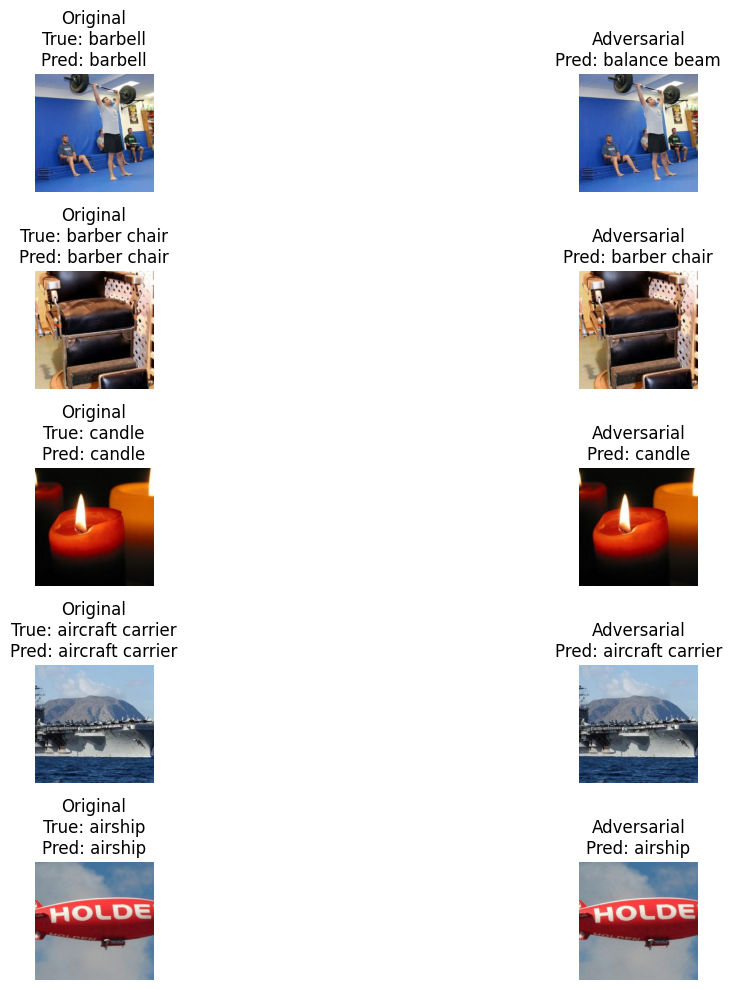

In [24]:

# Visualization
def denormalize(tensor):
    """Convert normalized tensor to PIL image"""
    tensor = tensor.clone().cpu()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return transforms.ToPILImage()(tensor)

valid_indices = []
for idx in range(len(adv_dataset)):
    adv_img, label = adv_dataset[idx]
    label_int = label.item() + 401
    true_class = idx_to_class.get(label_int, "Unknown Class")

    orig_img_tensor = dataset[idx][0].unsqueeze(0).to(device)
    with torch.no_grad():
        orig_pred = pretrained_model(orig_img_tensor).argmax().item()
    orig_class = idx_to_class.get(orig_pred, "Unknown Class")

    adv_img_tensor = adv_img.unsqueeze(0).to(device)
    with torch.no_grad():
        adv_pred = pretrained_model(adv_img_tensor).argmax().item()
    adv_class = idx_to_class.get(adv_pred, "Unknown Class")

    if "Unknown Class" not in [true_class, orig_class, adv_class]:
        valid_indices.append(idx)

# Visualize 5 random adversarial examples
sample_indices = random.sample(valid_indices, min(5, len(valid_indices)))

# Modify the visualization section with error handling
plt.figure(figsize=(15, 10))
for i, idx in enumerate(sample_indices):
    adv_img, label = adv_dataset[idx]

    # Convert tensors to integers
    label_int = label.item() + 401
    orig_img_tensor = dataset[idx][0].unsqueeze(0).to(device)
    adv_img_tensor = adv_img.unsqueeze(0).to(device)

    # Get predictions
    with torch.no_grad():
        orig_pred = pretrained_model(orig_img_tensor).argmax().item()
        adv_pred = pretrained_model(adv_img_tensor).argmax().item()

    # Handle unknown classes
    true_class = idx_to_class.get(label_int, "Unknown Class")
    orig_class = idx_to_class.get(orig_pred, "Unknown Class")
    adv_class = idx_to_class.get(adv_pred, "Unknown Class")

    # Original image
    plt.subplot(5, 2, 2*i+1)
    plt.imshow(denormalize(dataset[idx][0]))
    plt.title(f"Original\nTrue: {true_class}\nPred: {orig_class}")
    plt.axis('off')

    # Adversarial image
    plt.subplot(5, 2, 2*i+2)
    plt.imshow(denormalize(adv_img))
    plt.title(f"Adversarial\nPred: {adv_class}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [25]:
# ===== TASK 3: IMPROVED ATTACKS (PGD) =====

def pgd_attack(model, images, labels, epsilon=0.02, alpha=0.002, num_iter=5):
    """
    Multi-step PGD attack with random initialization
    """
    # Initialize perturbation
    delta = torch.zeros_like(images).to(device)
    delta.uniform_(-epsilon, epsilon)

    # Original images in normalized space
    orig_images = images.clone().detach()

    for _ in range(num_iter):
        delta.requires_grad = True

        # Forward pass with perturbed images
        outputs = model(orig_images + delta)
        loss = nn.CrossEntropyLoss()(outputs, labels + 401)  # Adjusted labels

        # Compute gradients
        model.zero_grad()
        loss.backward()

        # Update perturbation with gradient sign
        grad = delta.grad.detach()
        delta.data = delta.data + alpha * grad.sign()

        # Project back to ε-ball
        delta.data = torch.clamp(delta.data, -epsilon, epsilon)

        # Clamp to valid image space
        for c in range(3):
            lower = (0 - mean[c])/std[c] - orig_images[:, c, :, :]
            upper = (1 - mean[c])/std[c] - orig_images[:, c, :, :]
            delta[:, c, :, :].data = torch.clamp(
                delta[:, c, :, :],
                min=lower,
                max=upper
            )

    return (orig_images + delta).detach()

# Attack parameters
epsilon = 0.02  # Same as Task 2
alpha = epsilon / 10  # Step size
num_iter = 20    # Number of PGD steps

# Generate adversarial dataset
adv_images2 = []
true_labels2 = []

for images, labels in tqdm(loader, desc="Generating PGD Adversarial Examples"):
    images, labels = images.to(device), labels.to(device)

    # Generate adversarial examples
    perturbed = pgd_attack(pretrained_model, images, labels,
                          epsilon, alpha, num_iter)

    adv_images2.append(perturbed.cpu())
    true_labels2.append(labels.cpu())

# Create adversarial dataset
adv_images2 = torch.cat(adv_images2)
true_labels2 = torch.cat(true_labels2)
adv_dataset2 = torch.utils.data.TensorDataset(adv_images2, true_labels2)
adv_loader2 = DataLoader(adv_dataset2, batch_size=32, shuffle=False)

# Save adversarial examples
torch.save({
    'adv_images': adv_images2,
    'true_labels': true_labels2
}, 'Adversarial_Test_Set_2.pt')

# Evaluate performance
print("\nTask 3: Improved Attack (PGD) Evaluation")
top1_adv2, top5_adv2 = evaluate(pretrained_model, adv_loader2)
print(f"Top-1: {top1_adv2*100:.2f}%, Top-5: {top5_adv2*100:.2f}%")
print(f"Accuracy Drop: {top1_orig*100 - top1_adv2*100:.2f}pp (Top-1)")


Generating PGD Adversarial Examples: 100%|██████████| 16/16 [00:47<00:00,  2.98s/it]



Task 3: Improved Attack (PGD) Evaluation
Top-1: 0.20%, Top-5: 10.60%
Accuracy Drop: 75.80pp (Top-1)


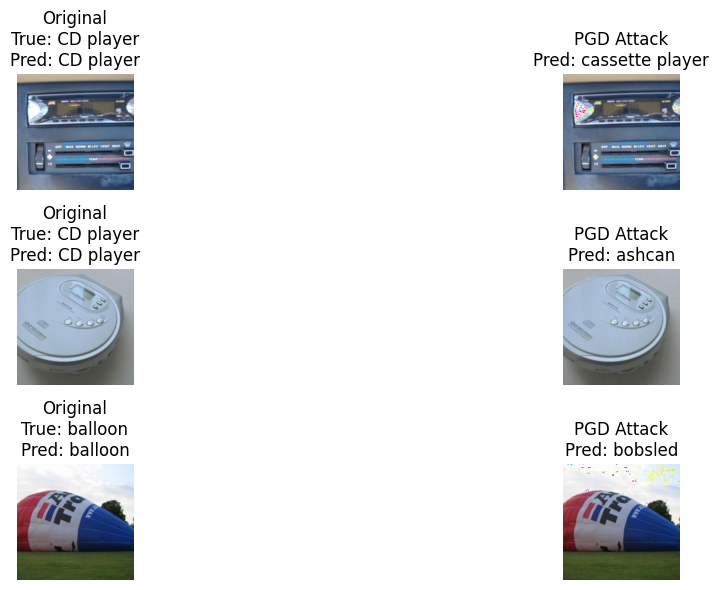

In [26]:
# Visualization (for Task 3 - PGD Attack)
# =======================================

# Collect valid indices where all classes are known
valid_indices = []
for idx in range(len(adv_dataset2)):  # Use adv_dataset2 for PGD
    adv_img, label = adv_dataset2[idx]
    label_int = label.item() + 401
    true_class = idx_to_class.get(label_int, "Unknown")

    orig_img_tensor = dataset[idx][0].unsqueeze(0).to(device)
    with torch.no_grad():
        orig_pred = pretrained_model(orig_img_tensor).argmax().item()
    orig_class = idx_to_class.get(orig_pred, "Unknown")

    adv_img_tensor = adv_img.unsqueeze(0).to(device)
    with torch.no_grad():
        adv_pred = pretrained_model(adv_img_tensor).argmax().item()
    adv_class = idx_to_class.get(adv_pred, "Unknown")

    if "Unknown" not in [true_class, orig_class, adv_class]:
        valid_indices.append(idx)

# Randomly select up to 3 valid indices
sample_indices = random.sample(valid_indices, min(3, len(valid_indices)))

# Visualization with 3 samples
plt.figure(figsize=(15, 6))  # Adjusted height for 3 samples
for i, idx in enumerate(sample_indices):
    adv_img, label = adv_dataset2[idx]  # Ensure using adv_dataset2

    # Convert tensors to integers
    label_int = label.item() + 401
    orig_img = dataset[idx][0]

    # Get predictions
    with torch.no_grad():
        orig_pred = pretrained_model(orig_img.unsqueeze(0).to(device)).argmax().item()
        adv_pred = pretrained_model(adv_img.unsqueeze(0).to(device)).argmax().item()

    # Handle classes
    true_class = idx_to_class.get(label_int, "Unknown")
    orig_class = idx_to_class.get(orig_pred, "Unknown")
    adv_class = idx_to_class.get(adv_pred, "Unknown")

    # Original image
    plt.subplot(3, 2, 2*i+1)  # Changed to 3 rows
    plt.imshow(denormalize(orig_img))
    plt.title(f"Original\nTrue: {true_class}\nPred: {orig_class}")
    plt.axis('off')

    # Adversarial image
    plt.subplot(3, 2, 2*i+2)  # Changed to 3 rows
    plt.imshow(denormalize(adv_img))
    plt.title(f"PGD Attack\nPred: {adv_class}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [42]:
# ===== TASK 4: PATCH ATTACKS (FIXED & OPTIMIZED) =====
def patch_attack(model, images, labels, epsilon=0.5, patch_size=32, num_iter=50, alpha=0.1):
    """
    Enhanced patch attack with proper label handling
    """
    # Normalization parameters
    mean_tensor = torch.tensor(mean).view(1, 3, 1, 1).to(device)
    std_tensor = torch.tensor(std).view(1, 3, 1, 1).to(device)

    batch_size, _, h, w = images.shape
    delta = torch.zeros_like(images).to(device)
    masks = torch.zeros_like(images)

    # Generate random patch positions
    x = torch.randint(0, h - patch_size, (batch_size,))
    y = torch.randint(0, w - patch_size, (batch_size,))

    for i in range(batch_size):
        masks[i, :, x[i]:x[i]+patch_size, y[i]:y[i]+patch_size] = 1

    # Initialize perturbation
    delta.data.uniform_(-epsilon, epsilon).mul_(masks)

    # Get least likely classes with proper label conversion
    with torch.no_grad():
        outputs = model(images)
        _, target_labels = torch.topk(-outputs, 1)
        target_labels = target_labels.squeeze()

    # Attack loop
    for _ in range(num_iter):
        delta.requires_grad = True
        adv_images = torch.clamp(images + delta,
                               (0 - mean_tensor)/std_tensor,
                               (1 - mean_tensor)/std_tensor)

        outputs = model(adv_images)
        loss = nn.CrossEntropyLoss()(outputs, target_labels)

        model.zero_grad()
        loss.backward()

        # Update perturbation
        delta.data = delta.data - alpha * delta.grad.sign() * masks
        delta.data = torch.clamp(delta.data, -epsilon, epsilon) * masks

    return adv_images.detach()

# Attack parameters
epsilon = 0.5
patch_size = 32
num_iter = 50  # Increased iterations
alpha = 0.1    # More aggressive step size

# Generate adversarial dataset
adv_images3 = []
true_labels3 = []

for images, labels in tqdm(loader, desc="Generating Patch Adversarial Examples"):
    images = images.to(device)
    perturbed = patch_attack(pretrained_model, images, labels, epsilon, patch_size, num_iter, alpha)

    adv_images3.append(perturbed.cpu())
    true_labels3.append(labels.cpu())
# After generating adv_images3 and true_labels3:
adv_images3 = torch.cat(adv_images3)
true_labels3 = torch.cat(true_labels3)
adv_dataset3 = torch.utils.data.TensorDataset(adv_images3, true_labels3)  # Define adv_dataset3

# Then evaluate:
print("\\nTask 4: Enhanced Patch Attack Evaluation")
top1_adv3, top5_adv3 = evaluate(pretrained_model, DataLoader(adv_dataset3, batch_size=32))
# Save and evaluate
torch.save({
    'adv_images': adv_images3,
    'true_labels': true_labels3
}, 'Adversarial_Test_Set_3.pt')

print("\nTask 4: Enhanced Patch Attack Evaluation")
top1_adv3, top5_adv3 = evaluate(pretrained_model, DataLoader(adv_dataset3, batch_size=32))
print(f"Top-1: {top1_adv3*100:.2f}%, Top-5: {top5_adv3*100:.2f}%")
print(f"Accuracy Drop: {top1_orig*100 - top1_adv3*100:.2f}pp (Top-1)")


Generating Patch Adversarial Examples: 100%|██████████| 16/16 [02:01<00:00,  7.62s/it]


\nTask 4: Enhanced Patch Attack Evaluation

Task 4: Enhanced Patch Attack Evaluation
Top-1: 59.60%, Top-5: 84.00%
Accuracy Drop: 16.40pp (Top-1)


Generating Patch Adversarial Examples: 100%|██████████| 16/16 [02:32<00:00,  9.51s/it]


\nTask 4: Enhanced Patch Attack Evaluation

Task 4: Enhanced Patch Attack Evaluation
Top-1: 62.00%, Top-5: 84.80%
Accuracy Drop: 14.00pp (Top-1)


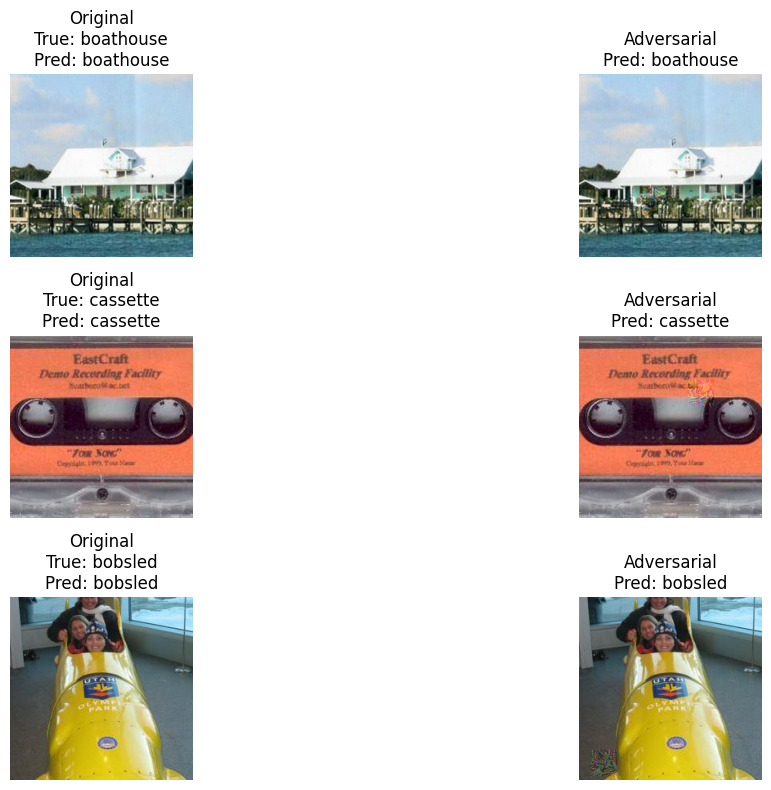

In [67]:

#visualization
valid_indices = []
for idx in range(len(adv_dataset)):
    adv_img, label = adv_dataset[idx]
    label_int = label.item() + 401
    true_class = idx_to_class.get(label_int, "Unknown Class")

    orig_img_tensor = dataset[idx][0].unsqueeze(0).to(device)
    with torch.no_grad():
        orig_pred = pretrained_model(orig_img_tensor).argmax().item()
    orig_class = idx_to_class.get(orig_pred, "Unknown Class")

    adv_img_tensor = adv_img.unsqueeze(0).to(device)
    with torch.no_grad():
        adv_pred = pretrained_model(adv_img_tensor).argmax().item()
    adv_class = idx_to_class.get(adv_pred, "Unknown Class")

    if "Unknown Class" not in [true_class, orig_class, adv_class]:
        valid_indices.append(idx)

sample_indices = random.sample(valid_indices, min(3, len(valid_indices)))

plt.figure(figsize=(15, 8))
for i in range(3):
    idx = random.randint(0, len(adv_dataset3)-1)
    adv_img, label = adv_dataset3[idx]
    label_int = label.item() + 401  # Convert tensor to integer

    with torch.no_grad():
        orig_pred = pretrained_model(dataset[idx][0].unsqueeze(0).to(device)).argmax().item()
        adv_pred = pretrained_model(adv_img.unsqueeze(0).to(device)).argmax().item()

    plt.subplot(3, 2, 2*i+1)
    plt.imshow(denormalize(dataset[idx][0]))
    plt.title(f"Original\nTrue: {idx_to_class.get(label_int, 'Unknown')}\nPred: {idx_to_class.get(orig_pred, 'Unknown')}")
    plt.axis('off')

    plt.subplot(3, 2, 2*i+2)
    plt.imshow(denormalize(adv_img))
    plt.title(f"Adversarial\nPred: {idx_to_class.get(adv_pred, 'Unknown')}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [29]:
# ===== TASK 5: TRANSFERRING ATTACKS (FIXED) =====
import torch
from torch.utils.data import TensorDataset, DataLoader

# Load DenseNet-121 model for transfer attack evaluation
transfer_model = torchvision.models.densenet121(weights='IMAGENET1K_V1').to(device)
transfer_model.eval()  # Add this critical line

def load_adversarial_dataset(path):
    """Handles both dictionary and TensorDataset formats"""
    data = torch.load(path)

    if isinstance(data, dict):  # New format
        images = data['adv_images']
        labels = data['true_labels']
    elif isinstance(data, TensorDataset):  # Legacy format
        images, labels = data.tensors
    else:
        raise ValueError("Unsupported dataset format")

    if not isinstance(labels, torch.Tensor):
        labels = torch.tensor(labels)

    return DataLoader(TensorDataset(images, labels), batch_size=32, shuffle=False)

# Load datasets
datasets = {
    'Original': loader,
    'FGSM': load_adversarial_dataset('Adversarial_Test_Set_1.pt'),
    'PGD': load_adversarial_dataset('Adversarial_Test_Set_2.pt'),
    'Patch': load_adversarial_dataset('Adversarial_Test_Set_3.pt')
}

# Evaluation function with proper label handling
print("\nTask 5: Transfer Attack Results (DenseNet-121)")
print("{:<10} {:<10} {:<10}".format('Dataset', 'Top-1', 'Top-5'))
print("-" * 35)

for name, dl in datasets.items():
    top1, top5 = evaluate(transfer_model, dl)  # Now using properly defined model
    print("{:<10} {:<10.2f}% {:<10.2f}%".format(name, top1*100, top5*100))  # Fixed format string


Task 5: Transfer Attack Results (DenseNet-121)
Dataset    Top-1      Top-5     
-----------------------------------
Original   74.80     % 93.60     %
FGSM       63.00     % 89.40     %
PGD        61.00     % 90.00     %
Patch      73.20     % 91.20     %
